# PolitiFact — Preprocessing

- Basic EDA
- Data cleaning
- Merge LLM ratings with human annotations
- Save cleaned data for analysis

In [1]:
import pandas as pd
# show all columns
pd.set_option('display.max_columns', None)
import numpy as np
import missingno as mn

## LLM ratings
Each of the 120 PolitiFact statements received exactly one rating from the LLM.

### S3 (3-point scale)

In [2]:
llm_ratings_s3 = pd.read_csv("../data/llm_ratings_truth_s3_gpt-4o-mini.csv")

# missing data?
print(f"Missing data in LLM Ratings: {llm_ratings_s3.isnull().sum().sum()}")

#shape
print(f"LLM Ratings shape: {llm_ratings_s3.shape}")

llm_ratings_s3.head()

Missing data in LLM Ratings: 0
LLM Ratings shape: (120, 2)


,statement,rating
0,22 times Barack Obama said he did not have the...,1.0
1,6400 Ohioans lost manufacturing jobs in the m...,2.0
2,98 percent of small businesses make less than ...,1.0
3,A recent economic uptick appears to coincide w...,1.0
4,According to Wikipedia there are only five cou...,1.0


### S6 (6-point scale)


In [3]:
llm_ratings_s6 = pd.read_csv("../data/llm_ratings_truth_s6_gpt-4o-mini.csv")

# missing data?
print(f"Missing data in LLM Ratings: {llm_ratings_s6.isnull().sum().sum()}")

#shape
print(f"LLM Ratings shape: {llm_ratings_s6.shape}")

llm_ratings_s6.head()


Missing data in LLM Ratings: 0
LLM Ratings shape: (120, 2)


,statement,rating
0,22 times Barack Obama said he did not have the...,3.0
1,6400 Ohioans lost manufacturing jobs in the m...,4.0
2,98 percent of small businesses make less than ...,4.0
3,A recent economic uptick appears to coincide w...,3.0
4,According to Wikipedia there are only five cou...,2.0


## Human annotations
- 120 statements × 55 columns (1 text + 54 human annotators).
- Each `unit_x` column corresponds to a unique crowd worker.
- NaNs represent missing annotations (many workers did not rate all statements).

### S3 (3-point scale)


In [4]:
human_judgments_s3 = pd.read_csv("../data/reliability_matrix_s3.csv")

# missing data?
print(f"Missing data in Human Judgments: {human_judgments_s3.isnull().sum().sum()}")

# shape
print(f"Human Judgments shape: {human_judgments_s3.shape}")

human_judgments_s3.head()


Missing data in Human Judgments: 6156
Human Judgments shape: (120, 55)


,statement,unit_0,unit_1,unit_10,unit_100,unit_101,unit_102,unit_103,unit_104,unit_105,unit_106,unit_107,unit_108,unit_109,unit_11,unit_110,unit_111,unit_112,unit_113,unit_114,unit_115,unit_116,unit_117,unit_118,unit_119,unit_12,unit_120,unit_121,unit_122,unit_123,unit_124,unit_125,unit_126,unit_127,unit_128,unit_129,unit_13,unit_130,unit_131,unit_132,unit_133,unit_134,unit_135,unit_136,unit_137,unit_138,unit_139,unit_14,unit_140,unit_141,unit_142,unit_143,unit_144,unit_145,unit_146
0,22 times Barack Obama said he did not have the...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,NaN,2.0,NaN,2.0
2,98 percent of small businesses make less than ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

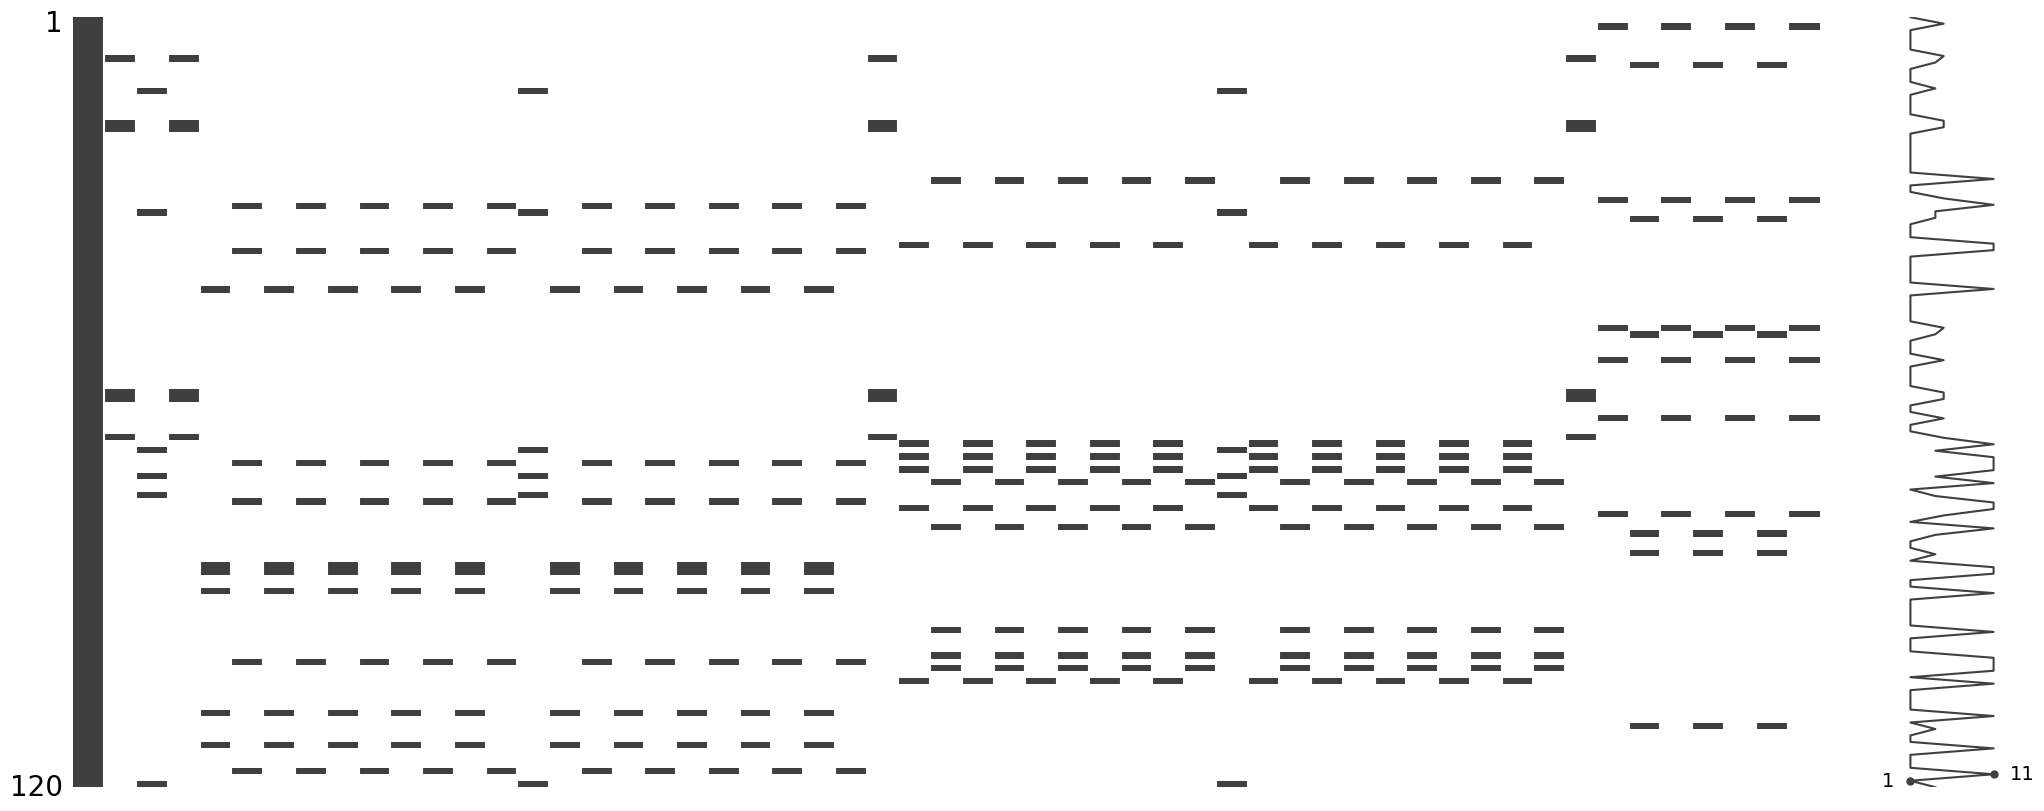

In [5]:
# show NaN pattern
mn.matrix(human_judgments_s3)


### S6 (6-point scale)


In [6]:
human_judgments_s6 = pd.read_csv("../data/reliability_matrix_s6.csv")

# missing data?
print(f"Missing data in Human Judgments: {human_judgments_s6.isnull().sum().sum()}")

# shape
print(f"Human Judgments shape: {human_judgments_s6.shape}")

human_judgments_s6.head()


Missing data in Human Judgments: 3420
Human Judgments shape: (120, 31)


,statement,unit_0,unit_1,unit_10,unit_100,unit_101,unit_102,unit_103,unit_104,unit_105,unit_106,unit_107,unit_108,unit_109,unit_11,unit_110,unit_111,unit_112,unit_113,unit_114,unit_115,unit_116,unit_117,unit_118,unit_119,unit_12,unit_120,unit_121,unit_122,unit_123,unit_124
0,22 times Barack Obama said he did not have the...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,98 percent of small businesses make less than ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

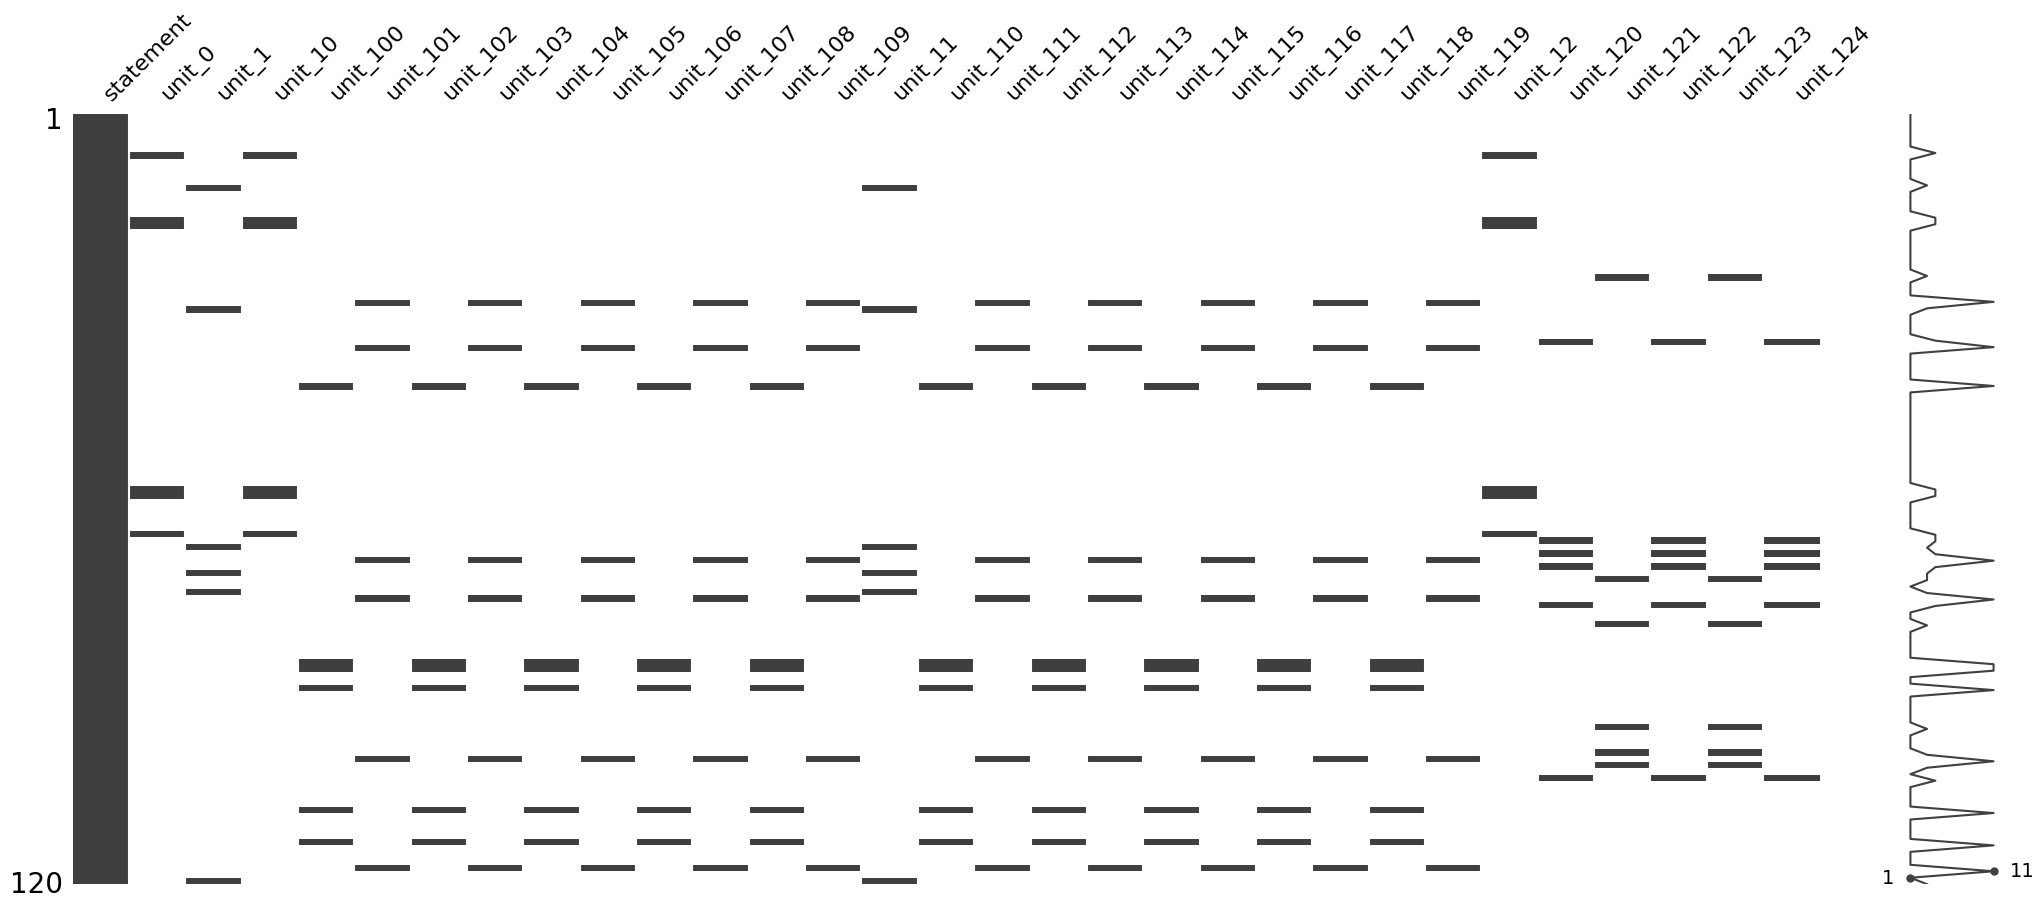

In [7]:
# show NaN pattern
mn.matrix(human_judgments_s6)


## Data cleaning & merging

### S3 dataset


In [8]:
# rename rating to LLM model name
llm_ratings_s3 = llm_ratings_s3.rename(columns={"rating": "GPT-4o mini"})

# rename unit_0 - unit_n to human_#1 - human_#n
human_judgments_s3.columns = ["statement"] + [f"human_#{i}" for i in range(1, len(human_judgments_s3.columns))]

# merge on 'statement'
merged_s3_df = pd.merge(llm_ratings_s3, human_judgments_s3, on="statement", how="inner")

# shape of merged df
print(f"Merged DataFrame shape: {merged_s3_df.shape}")

# gpt-4o-mini ratings unique values
print(f"Unique values in GPT-4o mini ratings: {merged_s3_df['GPT-4o mini'].unique()}")

# unique ratings across all human judges
human_cols = [c for c in merged_s3_df.columns if c.startswith("human_#")]
unique_human_ratings = np.unique(merged_s3_df[human_cols].values[~pd.isna(merged_s3_df[human_cols].values)])
print("Human rating scale:", unique_human_ratings)

merged_s3_df.head()


Merged DataFrame shape: (120, 56)
Unique values in GPT-4o mini ratings: [1. 2. 0.]
Human rating scale: [0. 1. 2.]


,statement,GPT-4o mini,human_#1,human_#2,human_#3,human_#4,human_#5,human_#6,human_#7,human_#8,human_#9,human_#10,human_#11,human_#12,human_#13,human_#14,human_#15,human_#16,human_#17,human_#18,human_#19,human_#20,human_#21,human_#22,human_#23,human_#24,human_#25,human_#26,human_#27,human_#28,human_#29,human_#30,human_#31,human_#32,human_#33,human_#34,human_#35,human_#36,human_#37,human_#38,human_#39,human_#40,human_#41,human_#42,human_#43,human_#44,human_#45,human_#46,human_#47,human_#48,human_#49,human_#50,human_#51,human_#52,human_#53,human_#54
0,22 times Barack Obama said he did not have the...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,NaN,2.0,NaN,2.0
2,98 percent of small businesses make less than ...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### S6 dataset


In [9]:
# rename rating to LLM model name
llm_ratings_s6 = llm_ratings_s6.rename(columns={"rating": "GPT-4o mini"})

# rename unit_0 - unit_n to human_#1 - human_#n
human_judgments_s6.columns = ["statement"] + [f"human_#{i}" for i in range(1, len(human_judgments_s6.columns))]

# merge on 'statement'
merged_s6_df = pd.merge(llm_ratings_s6, human_judgments_s6, on="statement", how="inner")

# shape of merged df
print(f"Merged DataFrame shape: {merged_s6_df.shape}")

# gpt-4o-mini ratings unique values
print(f"Unique values in GPT-4o mini ratings: {merged_s6_df['GPT-4o mini'].unique()}")

# unique ratings across all human judges
human_cols = [c for c in merged_s6_df.columns if c.startswith("human_#")]
unique_human_ratings = np.unique(merged_s6_df[human_cols].values[~pd.isna(merged_s6_df[human_cols].values)])
print("Human rating scale:", unique_human_ratings)

merged_s6_df.head()


Merged DataFrame shape: (120, 32)
Unique values in GPT-4o mini ratings: [3. 4. 2. 1. 5.]
Human rating scale: [0. 1. 2. 3. 4. 5.]


,statement,GPT-4o mini,human_#1,human_#2,human_#3,human_#4,human_#5,human_#6,human_#7,human_#8,human_#9,human_#10,human_#11,human_#12,human_#13,human_#14,human_#15,human_#16,human_#17,human_#18,human_#19,human_#20,human_#21,human_#22,human_#23,human_#24,human_#25,human_#26,human_#27,human_#28,human_#29,human_#30
0,22 times Barack Obama said he did not have the...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,98 percent of small businesses make less than ...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Save cleaned data


In [10]:
# Save S3 cleaned data
merged_s3_df.to_csv("../data/merged_s3_cleaned.csv", index=False)
print(f"✅ Saved S3 cleaned data to ../data/merged_s3_cleaned.csv ({merged_s3_df.shape[0]} rows, {merged_s3_df.shape[1]} columns)")

# Save S6 cleaned data
merged_s6_df.to_csv("../data/merged_s6_cleaned.csv", index=False)
print(f"✅ Saved S6 cleaned data to ../data/merged_s6_cleaned.csv ({merged_s6_df.shape[0]} rows, {merged_s6_df.shape[1]} columns)")


✅ Saved S3 cleaned data to ../data/merged_s3_cleaned.csv (120 rows, 56 columns)
✅ Saved S6 cleaned data to ../data/merged_s6_cleaned.csv (120 rows, 32 columns)
